In [17]:
# Imports
import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
import pandas as pd
import time
import os
from scipy.stats import norm, probplot, gaussian_kde
from core import LongitudinalOPEData
from nested_dr_kpt import NestedDRKPT
from longitudinal_datasets import LongitudinalSyntheticDataset

In [18]:
def run_longitudinal_tests(
    scenario_list,
    method_list,
    sample_size_list,
    num_experiments,
    name_folder,
    K=1,
    d=5,
    reg_lambda=1e-2,
):
    os.makedirs(name_folder, exist_ok=True)

    nested_cf = NestedDRKPT(reg_lambda=reg_lambda, cross_fit=True)
    nested_full = NestedDRKPT(reg_lambda=reg_lambda, cross_fit=False)

    for scenario_id in scenario_list:
        print(f"Scenario {scenario_id}")
        for method in method_list:
            for ns in sample_size_list:
                p_values = np.zeros(num_experiments)
                stats = np.zeros(num_experiments)
                times = np.zeros(num_experiments)

                for seed in range(num_experiments):
                    ds = LongitudinalSyntheticDataset(
                        scenario_id, K=K, ns=ns, d=d, seed=seed
                    )
                    data = ds.prepare_ope_data()

                    try:
                        t0 = time.time()
                        if method == "NestedDR-CF":
                            result = nested_cf.test(data)
                        elif method == "NestedDR":
                            result = nested_full.test(data)
                        else:
                            raise ValueError(f"Unknown method: {method}")
                        stat, pval = result["stat"], result["pval"]
                        elapsed = time.time() - t0
                    except Exception as e:
                        print(f"  seed={seed} method={method} ns={ns}: {e}")
                        stat, pval, elapsed = np.nan, np.nan, 0.0

                    p_values[seed] = pval
                    stats[seed] = stat
                    times[seed] = elapsed

                df = pd.DataFrame({"p_value": p_values, "stat": stats, "time": times})
                fname = f"{name_folder}/ns{ns}_longitudinal_scenario{scenario_id}_{method}.csv"
                df.to_csv(fname, index=False)
                print(f"  Saved: {fname}")

In [19]:
# Scenario I (null) — false positive rate calibration
run_longitudinal_tests(
    scenario_list=["I"],
    method_list=["NestedDR-CF"],
    sample_size_list=list(np.arange(100, 550, 50)),
    num_experiments=100,
    name_folder="results",
)

Scenario I
  Saved: results/ns100_longitudinal_scenarioI_NestedDR-CF.csv
  Saved: results/ns150_longitudinal_scenarioI_NestedDR-CF.csv
  Saved: results/ns200_longitudinal_scenarioI_NestedDR-CF.csv
  Saved: results/ns250_longitudinal_scenarioI_NestedDR-CF.csv
  Saved: results/ns300_longitudinal_scenarioI_NestedDR-CF.csv
  Saved: results/ns350_longitudinal_scenarioI_NestedDR-CF.csv
  Saved: results/ns400_longitudinal_scenarioI_NestedDR-CF.csv
  Saved: results/ns450_longitudinal_scenarioI_NestedDR-CF.csv
  Saved: results/ns500_longitudinal_scenarioI_NestedDR-CF.csv


In [20]:
# Scenarios II, III, IV — power curves
run_longitudinal_tests(
    scenario_list=["II", "III", "IV"],
    method_list=["NestedDR-CF"],
    sample_size_list=list(np.arange(100, 450, 50)),
    num_experiments=100,
    name_folder="results",
)

Scenario II
  Saved: results/ns100_longitudinal_scenarioII_NestedDR-CF.csv
  Saved: results/ns150_longitudinal_scenarioII_NestedDR-CF.csv
  Saved: results/ns200_longitudinal_scenarioII_NestedDR-CF.csv
  Saved: results/ns250_longitudinal_scenarioII_NestedDR-CF.csv
  Saved: results/ns300_longitudinal_scenarioII_NestedDR-CF.csv
  Saved: results/ns350_longitudinal_scenarioII_NestedDR-CF.csv
  Saved: results/ns400_longitudinal_scenarioII_NestedDR-CF.csv
Scenario III
  Saved: results/ns100_longitudinal_scenarioIII_NestedDR-CF.csv
  Saved: results/ns150_longitudinal_scenarioIII_NestedDR-CF.csv
  Saved: results/ns200_longitudinal_scenarioIII_NestedDR-CF.csv
  Saved: results/ns250_longitudinal_scenarioIII_NestedDR-CF.csv
  Saved: results/ns300_longitudinal_scenarioIII_NestedDR-CF.csv
  Saved: results/ns350_longitudinal_scenarioIII_NestedDR-CF.csv
  Saved: results/ns400_longitudinal_scenarioIII_NestedDR-CF.csv
Scenario IV
  Saved: results/ns100_longitudinal_scenarioIV_NestedDR-CF.csv
  Saved: re

In [21]:
# Load all longitudinal results
import glob

def load_longitudinal_results(folder="results/"):
    files = glob.glob(f"{folder}*longitudinal*.csv")
    return {f: pd.read_csv(f) for f in files}

d_results = load_longitudinal_results("results/")
print(f"Loaded {len(d_results)} result files")

Loaded 30 result files


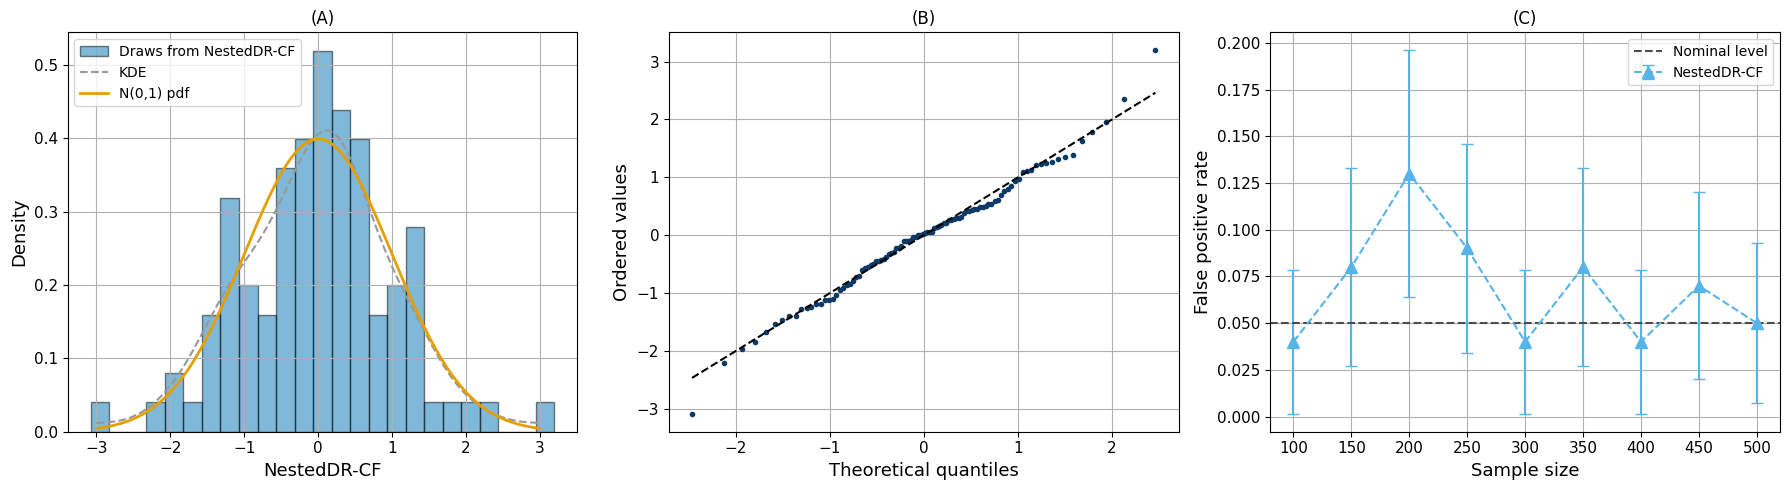

In [22]:
# Null diagnostics: histogram + QQ-plot + false-positive-rate vs n  (Scenario I)

def plot_null_diagnostics_longitudinal(
    d,
    scenario="I",
    method="NestedDR-CF",
    ns=300,
    name_folder="results/",
    ns_list=None,
    confidence_level=0.05,
    save_path="plots/null_longitudinal_scenarioI_errorbar.png",
):
    if ns_list is None:
        ns_list = list(np.arange(100, 550, 50))

    plt.rcParams["figure.figsize"] = (18, 5)
    plt.rcParams["axes.grid"] = True
    plt.rc("axes", labelsize=13)
    plt.rc("xtick", labelsize=11)
    plt.rc("ytick", labelsize=11)

    cb = {"hist": "#0072B2", "pdf": "#E69F00", "kde": "#999999",
          "qq": "#0D3B66", "errorbar": "#56B4E9", "nominal": "#4D4D4D"}

    fname = f"{name_folder}ns{ns}_longitudinal_scenario{scenario}_{method}.csv"
    stat_values = d[fname]["stat"]
    x_axis = np.linspace(-3, 3, 500)

    plt.subplot(1, 3, 1)
    plt.hist(stat_values, bins=25, density=True, color=cb["hist"], alpha=0.5,
             label=f"Draws from {method}", edgecolor="black")
    kde = gaussian_kde(stat_values)
    plt.plot(x_axis, kde(x_axis), color=cb["kde"], linestyle="--", label="KDE")
    plt.plot(x_axis, norm.pdf(x_axis), color=cb["pdf"], linewidth=2, label="N(0,1) pdf")
    plt.xlabel(method)
    plt.ylabel("Density")
    plt.title("(A)")
    plt.legend(loc="upper left")

    plt.subplot(1, 3, 2)
    osm, osr = probplot(stat_values, dist="norm")[0]
    plt.plot(osm, osr, marker="o", linestyle="", color=cb["qq"], markersize=3)
    plt.plot(osm, osm, color="black", linestyle="--")
    plt.title("(B)")
    plt.xlabel("Theoretical quantiles")
    plt.ylabel("Ordered values")

    plt.subplot(1, 3, 3)
    rejection_proportion = np.zeros(len(ns_list))
    for j, ns_val in enumerate(ns_list):
        fname_j = f"{name_folder}ns{ns_val}_longitudinal_scenario{scenario}_{method}.csv"
        pvals = d[fname_j]["p_value"]
        rejection_proportion[j] = (pvals < confidence_level).mean()

    varhat = rejection_proportion * (1 - rejection_proportion) / len(pvals)
    plt.errorbar(
        x=ns_list, y=rejection_proportion, yerr=1.96 * np.sqrt(varhat),
        capsize=4, marker="^", markersize=8, color=cb["errorbar"],
        linestyle="--", label=method
    )
    plt.axhline(confidence_level, color=cb["nominal"], linestyle="--", label="Nominal level")
    plt.title("(C)")
    plt.xlabel("Sample size")
    plt.ylabel("False positive rate")
    plt.legend(loc="upper right")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_null_diagnostics_longitudinal(
    d_results,
    scenario="I",
    method="NestedDR-CF",
    ns=300,
    name_folder="results/",
    ns_list=list(np.arange(100, 550, 50)),
    confidence_level=0.05,
    save_path="plots/null_longitudinal_scenarioI_errorbar.png",
)

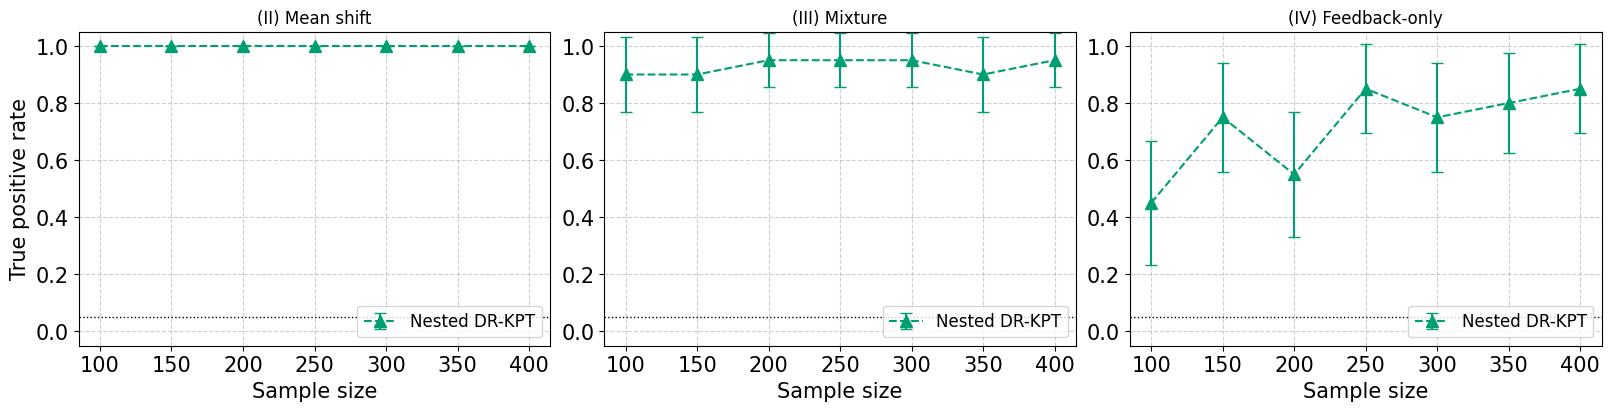

In [7]:
# Power curves for Scenarios II, III, IV

def plot_power_longitudinal(
    d,
    scenario_list=("II", "III", "IV"),
    ns_list=None,
    methods=("NestedDR-CF",),
    name_folder="results/",
    confidence_level=0.05,
    save_path="plots/longitudinal_scenarios234_errorbar.png",
):
    if ns_list is None:
        ns_list = list(np.arange(100, 450, 50))

    plt.rcParams["figure.figsize"] = (16, 4)
    plt.rc("legend", fontsize=12)
    plt.rc("axes", labelsize=15)
    plt.rc("xtick", labelsize=15)
    plt.rc("ytick", labelsize=15)
    plt.rcParams["axes.grid"] = True

    method_labels = {"NestedDR-CF": "Nested DR-KPT", "NestedDR": "Nested DR"}
    colors = {"NestedDR-CF": "#009E73", "NestedDR": "#0072B2"}
    markers = {"NestedDR-CF": "^", "NestedDR": "s"}
    titles = {"II": "(II) Mean shift", "III": "(III) Mixture", "IV": "(IV) Feedback-only"}

    fig, axs = plt.subplots(1, len(scenario_list), constrained_layout=True)
    if len(scenario_list) == 1:
        axs = [axs]

    ns_array = np.array(ns_list)

    for col, scenario in enumerate(scenario_list):
        ax = axs[col]
        ax.set_title(titles.get(scenario, scenario))
        ax.set_ylim((-0.05, 1.05))
        ax.set_xlabel("Sample size")
        ax.set_xticks(ns_list)
        ax.grid(True, linestyle="--", alpha=0.6)
        if col == 0:
            ax.set_ylabel("True positive rate")

        for i, method in enumerate(methods):
            rejection_proportion = []
            for ns in ns_list:
                fname = f"{name_folder}ns{ns}_longitudinal_scenario{scenario}_{method}.csv"
                pvals = d[fname]["p_value"]
                rejection_proportion.append((pvals < confidence_level).mean())
            rejection_proportion = np.array(rejection_proportion)
            varhat = rejection_proportion * (1 - rejection_proportion) / len(pvals)
            ax.errorbar(
                x=ns_array, y=rejection_proportion,
                yerr=1.96 * np.sqrt(varhat),
                capsize=4, marker=markers.get(method, "o"),
                linestyle="--", linewidth=1.5, markersize=8,
                label=method_labels.get(method, method),
                color=colors.get(method, "#333333")
            )
        ax.axhline(confidence_level, color="black", linestyle=":", linewidth=1)
        ax.legend(loc="lower right")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_power_longitudinal(
    d=d_results,
    scenario_list=["II", "III", "IV"],
    ns_list=list(np.arange(100, 450, 50)),
    methods=["NestedDR-CF"],
    name_folder="results/",
    confidence_level=0.05,
    save_path="plots/longitudinal_scenarios234_errorbar.png",
)

In [ ]:
# Scenario IV comparison: NestedDR-CF vs non-nested DR-CF
# Requires running the non-nested DR-CF on the longitudinal Scenario IV data first.
# This cell runs both and overlays them on a single power plot.
#
# NOTE: to add DR-CF (non-nested) as a baseline, run:
#   from dr_kpt import DRKPT
#   from datasets import ... (wrap LongitudinalOPEData to flat OPEData using only stage K)
#
# This is left as a separate cell to be completed once baseline comparison data is generated.

print("Scenario IV comparison cell: run non-nested baseline separately, then overlay plots.")